# Projet Meteostat : Prédiction de Précipitations pour Systèmes Embarqués
Ce notebook présente différentes architectures de Deep Learning et de Machine Learning pour prédire la pluie à partir de données météo (Température, Humidité, Pression), avec une optimisation pour microcontrôleurs STM32.

## 1. Approche Initiale : Réseau Dense (MLP) et Quantification
Cette section présente un modèle simple de type perceptron multicouche, optimisé en Int8 pour une empreinte mémoire minimale.

In [2]:
!pip install meteostat

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 113.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.5/506.5 kB 51.6 MB/s eta 0:00:00
  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requi

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Couche_dense_1_32N (Dense)      │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Couche_dense_2_16N (Dense)      │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Couche_dense_3_8N (Dense)       │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Sortie_Probabilite (Dense)      │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801 (3.13 KB)

 Trainable params: 801 (3.13 KB)

 Non-trainable params: 0 (0.00 B)


--- Démarrage de l'apprentissage ---


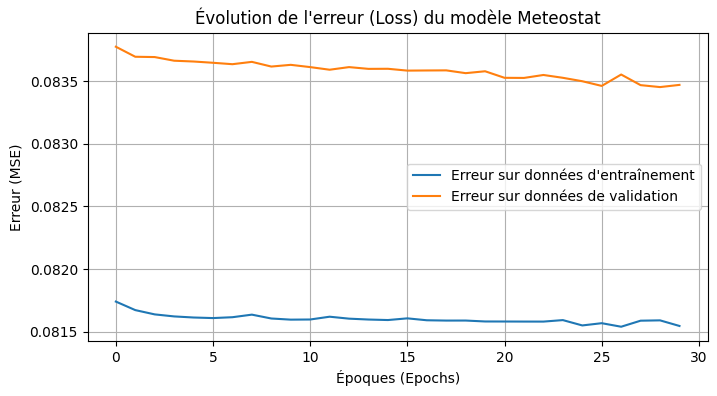

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step

--- Tests de prédiction ---
Entrées brutes (T, H, P): [  15.    95.1 1023.2] -> Probabilité prédite : 49.0%
Entrées brutes (T, H, P): [ 23.9  15.6 965.6] -> Probabilité prédite : 49.0%
Entrées brutes (T, H, P): [   2.3   86.6 1010.1] -> Probabilité prédite : 49.0%
Entrées brutes (T, H, P): [  28.3    2.1 1047. ] -> Probabilité prédite : 50.1%
Entrées brutes (T, H, P): [ 33.3  21.2 968.2] -> Probabilité prédite : 49.0%
Saved artifact at '/tmp/tmpezqp5ln9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='Entree_3_features')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133185111126864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133187514317520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133187514309072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133183297676752: TensorSpec(shape=(), dtype=tf.

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# =====================================================================
# 1. PRÉPARATION DES DONNÉES (Le plus gros défi selon le cours)
# =====================================================================
# Création de données météo fictives pour l'exemple (à remplacer par l'API Meteostat)
np.random.seed(42)
# 1000 échantillons de : Température (0-40°C), Humidité (0-100%), Pression (950-1050 hPa)
X_brut = np.random.rand(1000, 3) * [40, 100, 100] + [0, 0, 950]
# Cible : Probabilité fictive de précipitation (entre 0 et 1)
y_cible = np.random.rand(1000, 1)

# Normalisation des données météo (Étape exigée par l'architecture)
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X_brut)

# =====================================================================
# 2. ARCHITECTURE DU MODÈLE (Conforme au schéma du cours)
# =====================================================================
model = models.Sequential([
    layers.InputLayer(input_shape=(3,), name='Entree_3_features'),
    layers.Dense(32, activation='relu', name='Couche_dense_1_32N'),
    layers.Dense(16, activation='relu', name='Couche_dense_2_16N'),
    layers.Dense(8, activation='relu', name='Couche_dense_3_8N'),
    layers.Dense(1, activation='sigmoid', name='Sortie_Probabilite') # Activation sigmoïde pour 0-100%
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

# =====================================================================
# 3. ENTRAÎNEMENT HORS-LIGNE
# =====================================================================
print("\n--- Démarrage de l'apprentissage ---")
history = model.fit(X_norm, y_cible, epochs=30, batch_size=16, validation_split=0.2, verbose=0)

# Affichage optimal sous forme de graphique pour analyser l'apprentissage
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Erreur sur données d\'entraînement')
plt.plot(history.history['val_loss'], label='Erreur sur données de validation')
plt.title('Évolution de l\'erreur (Loss) du modèle Meteostat')
plt.xlabel('Époques (Epochs)')
plt.ylabel('Erreur (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Affichage de quelques prédictions
predictions = model.predict(X_norm[:5])
print("\n--- Tests de prédiction ---")
for i in range(5):
    print(f"Entrées brutes (T, H, P): {X_brut[i].round(1)} -> Probabilité prédite : {predictions[i][0]*100:.1f}%")

# =====================================================================
# 4. OPTIMISATION MAXIMALE POUR SYSTÈME EMBARQUÉ (STM32)
# =====================================================================
# Conversion en TensorFlow Lite avec Quantification int8
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Le modèle a besoin d'exemples de données pour calibrer la quantification (Int8)
def representative_data_gen():
    for i in range(100):
        # Fournir des échantillons un par un
        yield [X_norm[i:i+1].astype(np.float32)]

converter.representative_dataset = representative_data_gen
# Restreindre les opérations aux entiers 8-bits pour une taille/consommation minimale
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_quant_model = converter.convert()

# Sauvegarde du fichier à importer dans STM32CubeIDE via X-CUBE-AI
with open('meteostat_optimise_int8.tflite', 'wb') as f:
    f.write(tflite_quant_model)

print("\n✅ Modèle allégé, quantifié en Int8 et sauvegardé sous 'meteostat_optimise_int8.tflite' !")
print("Il est prêt à être déployé sur le microcontrôleur pour la phase d'inférence.")

🔄 1. Récupération et préparation des données météo...
✅ Données récupérées avec succès : 8760 relevés horaires.

🔄 2. Création de l'architecture et calcul des pénalités...
Poids attribué à 'Sec' (0) : 0.56
Poids attribué à 'Pluie' (1) : 4.73 -> L'erreur coûtera plus cher !

--- Démarrage de l'apprentissage ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


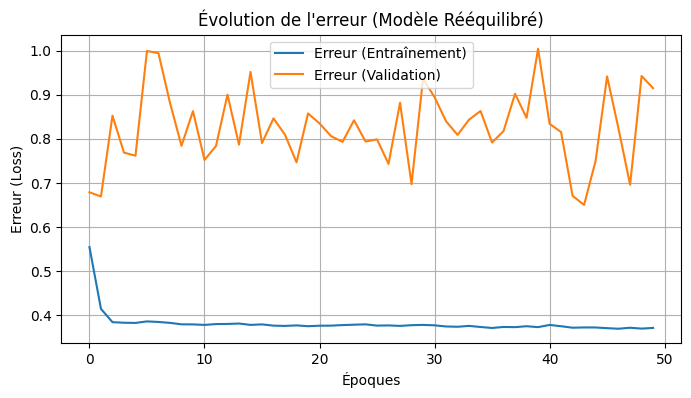


🔄 4. Évaluation des performances réelles...

Rapport de classification :
                  precision    recall  f1-score   support

Pas de pluie (0)       0.98      0.72      0.83      7834
       Pluie (1)       0.27      0.90      0.42       926

        accuracy                           0.74      8760
       macro avg       0.63      0.81      0.63      8760
    weighted avg       0.91      0.74      0.79      8760



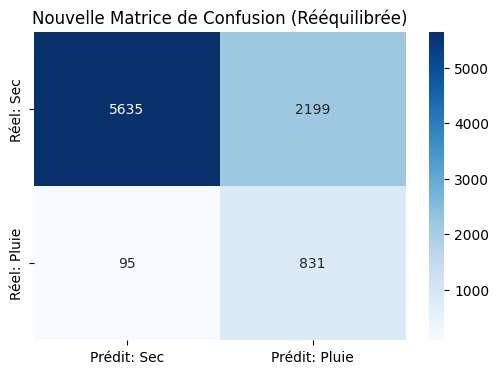


🔄 5. Conversion et Quantification Int8 pour STM32...
Saved artifact at '/tmp/tmp_h9il04t'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='Entree_3_features')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133185111114192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133187511163536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133187511166224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133187511169872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133185111120912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133185111128208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133185597351952: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133185597342544: TensorSpec(shape=(), dtype=tf.resource, name=None)

✅ TERMINÉ ! Le modèle est allégé, quantifié et sauvegardé sous 'meteostat_optimise_int8.tflite'.


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [ ]:
from datetime import datetime
import meteostat as ms
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. PRÉPARATION DES DONNÉES (Via la bibliothèque Python Meteostat)
# =====================================================================
print("🔄 1. Récupération et préparation des données météo...")

# Période temporelle (Une année complète pour avoir assez de pluie)
start = datetime(2023, 1, 1)
end = datetime(2023, 12, 31, 23, 59)

# Récupération des données horaires pour la station 10637 (Francfort)
data = ms.hourly('10637', start, end)
df = data.fetch()

# On garde uniquement les 3 entrées requises + la cible (précipitations)
df = df[['temp', 'rhum', 'pres', 'prcp']].dropna()

# Extraction des caractéristiques d'entrée
X_brut = df[['temp', 'rhum', 'pres']].values

# Création de la cible : 1 si la précipitation est > 0 (il pleut), 0 sinon
y_cible = (df['prcp'] > 0).astype(int).values

print(f"✅ Données récupérées avec succès : {len(X_brut)} relevés horaires.")

# Normalisation des données (Indispensable pour l'IA)
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X_brut)

# =====================================================================
# 2. ARCHITECTURE DU MODÈLE ET POIDS DE CLASSES
# =====================================================================
print("\n🔄 2. Création de l'architecture et calcul des pénalités...")

# Calcul automatique du poids idéal pour rééquilibrer "Sec" vs "Pluie"
poids_calcules = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_cible),
    y=y_cible
)
dico_poids = {0: poids_calcules[0], 1: poids_calcules[1]}
print(f"Poids attribué à 'Sec' (0) : {dico_poids[0]:.2f}")
print(f"Poids attribué à 'Pluie' (1) : {dico_poids[1]:.2f} -> L'erreur coûtera plus cher !")

# Architecture stricte du TP
model = models.Sequential([
    layers.InputLayer(input_shape=(3,), name='Entree_3_features'),
    layers.Dense(32, activation='relu', name='Couche_dense_1_32N'),
    layers.Dense(16, activation='relu', name='Couche_dense_2_16N'),
    layers.Dense(8, activation='relu', name='Couche_dense_3_8N'),
    layers.Dense(1, activation='sigmoid', name='Sortie_Probabilite')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# =====================================================================
# 3. ENTRAÎNEMENT HORS-LIGNE
# =====================================================================
print("\n--- Démarrage de l'apprentissage ---")
history = model.fit(
    X_norm, y_cible,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=dico_poids, # Application du rééquilibrage
    verbose=0
)

# 3.1 Affichage de l'évolution de l'erreur
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Erreur (Entraînement)')
plt.plot(history.history['val_loss'], label='Erreur (Validation)')
plt.title("Évolution de l'erreur (Modèle Rééquilibré)")
plt.xlabel("Époques")
plt.ylabel("Erreur (Loss)")
plt.legend()
plt.grid(True)
plt.show()

# =====================================================================
# 4. ÉVALUATION CONCRÈTE DU MODÈLE
# =====================================================================
print("\n🔄 4. Évaluation des performances réelles...")

y_pred_proba = model.predict(X_norm, verbose=0)
y_pred_binaire = (y_pred_proba > 0.5).astype(int)

# 4.1 Rapport et Matrice de confusion
print("\nRapport de classification :")
print(classification_report(y_cible, y_pred_binaire, target_names=['Pas de pluie (0)', 'Pluie (1)']))

matrice = confusion_matrix(y_cible, y_pred_binaire)
plt.figure(figsize=(6, 4))
sns.heatmap(matrice, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit: Sec', 'Prédit: Pluie'],
            yticklabels=['Réel: Sec', 'Réel: Pluie'])
plt.title('Nouvelle Matrice de Confusion (Rééquilibrée)')
plt.show()

# =====================================================================
# 5. OPTIMISATION MAXIMALE POUR SYSTÈME EMBARQUÉ (STM32)
# =====================================================================
print("\n🔄 5. Conversion et Quantification Int8 pour STM32...")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

def representative_data_gen():
    for i in range(min(100, len(X_norm))):
        yield [X_norm[i:i+1].astype(np.float32)]

converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_quant_model = converter.convert()

nom_fichier = 'meteostat_optimise_int8.tflite'
with open(nom_fichier, 'wb') as f:
    f.write(tflite_quant_model)

print(f"\n✅ TERMINÉ ! Le modèle est allégé, quantifié et sauvegardé sous '{nom_fichier}'.")

## 2. Approche Temporelle : Réseau Récurrent (RNN/LSTM)
Utilisation d'une fenêtre glissante de 24 heures pour capturer les dépendances temporelles de la météo.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


🔄 1. Récupération des données...

🔄 2. Création de l'architecture RNN stabilisée...

--- Démarrage de l'apprentissage ---


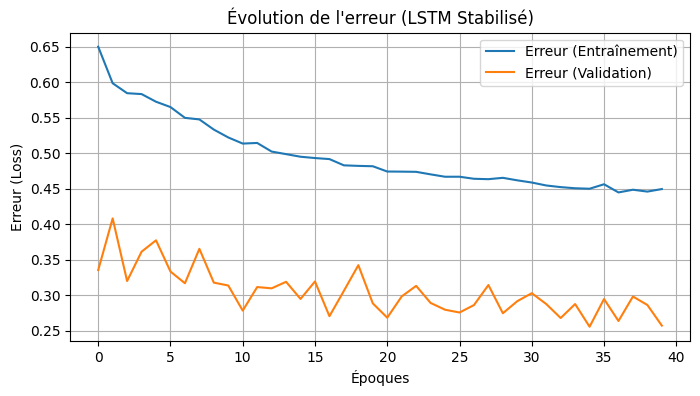


🔄 4. Évaluation sur les données de test...

Rapport de classification :
              precision    recall  f1-score   support

Pas de pluie       0.94      0.93      0.94      1560
       Pluie       0.47      0.48      0.48       188

    accuracy                           0.89      1748
   macro avg       0.70      0.71      0.71      1748
weighted avg       0.89      0.89      0.89      1748



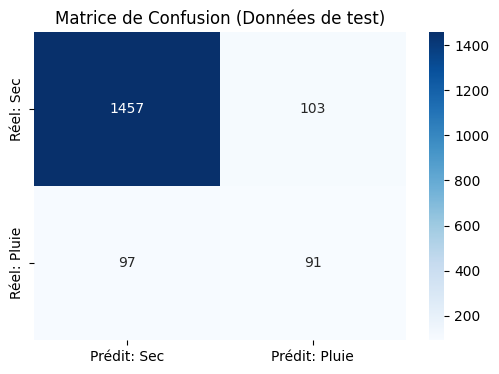

In [ ]:
from datetime import datetime
import meteostat as ms
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. PRÉPARATION DES DONNÉES ET SÉQUENCES
# =====================================================================
print("🔄 1. Récupération des données...")
start = datetime(2023, 1, 1)
end = datetime(2023, 12, 31, 23, 59)
data = ms.hourly('10637', start, end)
df = data.fetch()

df = df[['temp', 'rhum', 'pres', 'prcp']].dropna()
X_brut = df[['temp', 'rhum', 'pres']].values
y_brut = (df['prcp'] > 0).astype(int).values

scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X_brut)

# Création des séquences de 24h
SEQUENCE_LENGTH = 24
X_seq, y_seq = [], []
for i in range(len(X_norm) - SEQUENCE_LENGTH):
    X_seq.append(X_norm[i : i + SEQUENCE_LENGTH])
    y_seq.append(y_brut[i + SEQUENCE_LENGTH])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# ASTUCE 1 : On mélange aléatoirement les données pour éviter le "piège de l'hiver" à la fin
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

# =====================================================================
# 2. ARCHITECTURE LSTM STABILISÉE
# =====================================================================
print("\n🔄 2. Création de l'architecture RNN stabilisée...")

model = models.Sequential([
    layers.InputLayer(input_shape=(SEQUENCE_LENGTH, 3)),

    layers.LSTM(16, return_sequences=False),
    # ASTUCE 2 : Le Dropout (20% des neurones désactivés pour forcer la généralisation)
    layers.Dropout(0.2),

    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# On réduit légèrement le taux d'apprentissage (learning_rate) pour éviter les sauts brusques
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# ASTUCE 3 : Un poids modéré. 1 pour le temps sec, 3 pour la pluie.
dico_poids_moderes = {0: 1.0, 1: 3.0}

# =====================================================================
# 3. ENTRAÎNEMENT
# =====================================================================
print("\n--- Démarrage de l'apprentissage ---")
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_test, y_test), # On utilise nos données bien mélangées
    class_weight=dico_poids_moderes,
    verbose=0
)

# Affichage graphique
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Erreur (Entraînement)')
plt.plot(history.history['val_loss'], label='Erreur (Validation)')
plt.title("Évolution de l'erreur (LSTM Stabilisé)")
plt.xlabel("Époques")
plt.ylabel("Erreur (Loss)")
plt.legend()
plt.grid(True)
plt.show()

# =====================================================================
# 4. ÉVALUATION CONCRÈTE
# =====================================================================
print("\n🔄 4. Évaluation sur les données de test...")

y_pred_proba = model.predict(X_test, verbose=0)
y_pred_binaire = (y_pred_proba > 0.5).astype(int)

print("\nRapport de classification :")
print(classification_report(y_test, y_pred_binaire, target_names=['Pas de pluie', 'Pluie']))

matrice = confusion_matrix(y_test, y_pred_binaire)
plt.figure(figsize=(6, 4))
sns.heatmap(matrice, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit: Sec', 'Prédit: Pluie'], yticklabels=['Réel: Sec', 'Réel: Pluie'])
plt.title('Matrice de Confusion (Données de test)')
plt.show()

## 3. Approche Spatiale : Réseau Convolutif (1D-CNN)
Modèle optimisé pour le NPU (Neural Processing Unit) des nouveaux composants STM32, offrant un excellent compromis performance/consommation.

🔄 1. Récupération des données et séquençage...

🔄 2. Création de l'architecture 1D-CNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Couche_Conv1D_16Filtres         │ (None, 22, 16)         │           160 │
│ (Conv1D)                        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Couche_MaxPool (MaxPooling1D)   │ (None, 11, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Couche_Flatten (Flatten)        │ (None, 176)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Couche_Dense_8N (Dense)         │ (None, 8)              │         1,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_20pct (Dropout)         │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Sortie_Probabilite (Dense)      │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,585 (6.19 KB)

 Trainable params: 1,585 (6.19 KB)

 Non-trainable params: 0 (0.00 B)


--- Démarrage de l'apprentissage (CNN) ---


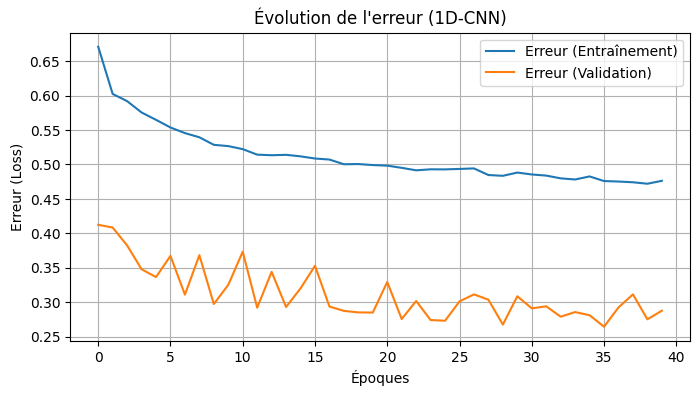


🔄 4. Évaluation sur les données de test...

Rapport de classification :
              precision    recall  f1-score   support

Pas de pluie       0.95      0.90      0.92      1560
       Pluie       0.41      0.59      0.48       188

    accuracy                           0.87      1748
   macro avg       0.68      0.74      0.70      1748
weighted avg       0.89      0.87      0.88      1748



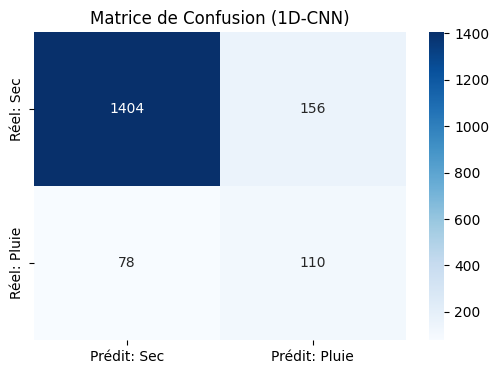


🔄 5. Conversion et Quantification Int8 pour STM32...
Saved artifact at '/tmp/tmp9tzu8j_z'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 3), dtype=tf.float32, name='Entree_Sequence_24h')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133185600818448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133185600822288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133185600818832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133182737343184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133182737337808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133182737341648: TensorSpec(shape=(), dtype=tf.resource, name=None)

✅ TERMINÉ ! Le modèle 1D-CNN est compilé, quantifié et prêt pour le NPU sous 'meteostat_cnn_int8.tflite'.


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [ ]:
from datetime import datetime
import meteostat as ms
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. PRÉPARATION DES DONNÉES ET SÉQUENCES
# =====================================================================
print("🔄 1. Récupération des données et séquençage...")
start = datetime(2023, 1, 1)
end = datetime(2023, 12, 31, 23, 59)
data = ms.hourly('10637', start, end)
df = data.fetch()

df = df[['temp', 'rhum', 'pres', 'prcp']].dropna()
X_brut = df[['temp', 'rhum', 'pres']].values
y_brut = (df['prcp'] > 0).astype(int).values

scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X_brut)

# Fenêtre glissante de 24h
SEQUENCE_LENGTH = 24
X_seq, y_seq = [], []
for i in range(len(X_norm) - SEQUENCE_LENGTH):
    X_seq.append(X_norm[i : i + SEQUENCE_LENGTH])
    y_seq.append(y_brut[i + SEQUENCE_LENGTH])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# Mélange des données pour une bonne généralisation
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

# =====================================================================
# 2. ARCHITECTURE 1D-CNN (Optimisée pour le NPU STM32N657)
# =====================================================================
print("\n🔄 2. Création de l'architecture 1D-CNN...")

model = models.Sequential([
    layers.InputLayer(input_shape=(SEQUENCE_LENGTH, 3), name='Entree_Sequence_24h'),

    # Le coeur du CNN : Un filtre glissant (kernel_size=3) qui lit la météo par blocs de 3 heures
    layers.Conv1D(filters=16, kernel_size=3, activation='relu', name='Couche_Conv1D_16Filtres'),

    # Réduction de la dimensionnalité pour alléger les calculs
    layers.MaxPooling1D(pool_size=2, name='Couche_MaxPool'),

    # Aplatissement pour passer aux neurones classiques
    layers.Flatten(name='Couche_Flatten'),

    # Couches denses et régularisation
    layers.Dense(8, activation='relu', name='Couche_Dense_8N'),
    layers.Dropout(0.2, name='Dropout_20pct'),
    layers.Dense(1, activation='sigmoid', name='Sortie_Probabilite')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

# Poids modérés pour rééquilibrer la pluie vs temps sec
dico_poids_moderes = {0: 1.0, 1: 3.0}

# =====================================================================
# 3. ENTRAÎNEMENT
# =====================================================================
print("\n--- Démarrage de l'apprentissage (CNN) ---")
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=dico_poids_moderes,
    verbose=0
)

# Affichage graphique
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Erreur (Entraînement)')
plt.plot(history.history['val_loss'], label='Erreur (Validation)')
plt.title("Évolution de l'erreur (1D-CNN)")
plt.xlabel("Époques")
plt.ylabel("Erreur (Loss)")
plt.legend()
plt.grid(True)
plt.show()

# =====================================================================
# 4. ÉVALUATION CONCRÈTE
# =====================================================================
print("\n🔄 4. Évaluation sur les données de test...")
y_pred_proba = model.predict(X_test, verbose=0)
y_pred_binaire = (y_pred_proba > 0.5).astype(int)

print("\nRapport de classification :")
print(classification_report(y_test, y_pred_binaire, target_names=['Pas de pluie', 'Pluie']))

matrice = confusion_matrix(y_test, y_pred_binaire)
plt.figure(figsize=(6, 4))
sns.heatmap(matrice, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit: Sec', 'Prédit: Pluie'], yticklabels=['Réel: Sec', 'Réel: Pluie'])
plt.title('Matrice de Confusion (1D-CNN)')
plt.show()

# =====================================================================
# 5. OPTIMISATION NATIVE POUR STM32 (TFLite Int8)
# =====================================================================
print("\n🔄 5. Conversion et Quantification Int8 pour STM32...")

# Contrairement au RNN, le CNN se convertit nativement et très facilement !
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

def representative_data_gen():
    for i in range(min(100, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]

converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_quant_model = converter.convert()

nom_fichier = 'meteostat_cnn_int8.tflite'
with open(nom_fichier, 'wb') as f:
    f.write(tflite_quant_model)

print(f"\n✅ TERMINÉ ! Le modèle 1D-CNN est compilé, quantifié et prêt pour le NPU sous '{nom_fichier}'.")

## 4. Approche Classique : Forêt Aléatoire (Random Forest)
Comparaison avec une méthode de Machine Learning traditionnelle pour évaluer le gain apporté par le Deep Learning.

🔄 1. Récupération des données et séquençage...

🔄 2. Entraînement de la Forêt Aléatoire (Machine Learning classique)...

🔄 3. Évaluation sur les données de test...

Rapport de classification :
              precision    recall  f1-score   support

Pas de pluie       0.96      0.89      0.92      1560
       Pluie       0.43      0.68      0.53       188

    accuracy                           0.87      1748
   macro avg       0.69      0.79      0.73      1748
weighted avg       0.90      0.87      0.88      1748



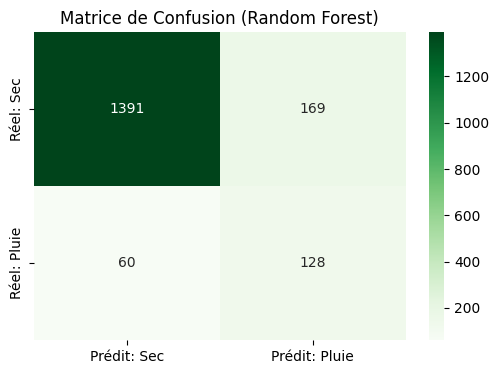

In [ ]:
from datetime import datetime
import meteostat as ms
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# 1. PRÉPARATION DES DONNÉES (Identique au CNN pour une comparaison juste)
# =====================================================================
print("🔄 1. Récupération des données et séquençage...")
start = datetime(2023, 1, 1)
end = datetime(2023, 12, 31, 23, 59)
data = ms.hourly('10637', start, end)
df = data.fetch()[['temp', 'rhum', 'pres', 'prcp']].dropna()

X_brut = df[['temp', 'rhum', 'pres']].values
y_brut = (df['prcp'] > 0).astype(int).values

scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X_brut)

# Création des fenêtres de 24h
SEQUENCE_LENGTH = 24
X_seq, y_seq = [], []
for i in range(len(X_norm) - SEQUENCE_LENGTH):
    X_seq.append(X_norm[i : i + SEQUENCE_LENGTH])
    y_seq.append(y_brut[i + SEQUENCE_LENGTH])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# ASTUCE : Le Random Forest n'aime pas la 3D.
# On "aplatit" les (24, 3) en une ligne de 72 variables.
X_seq_plat = X_seq.reshape(X_seq.shape[0], -1)

# Mélange des données
X_train, X_test, y_train, y_test = train_test_split(X_seq_plat, y_seq, test_size=0.2, random_state=42)

# =====================================================================
# 2. ENTRAÎNEMENT DU RANDOM FOREST
# =====================================================================
print("\n🔄 2. Entraînement de la Forêt Aléatoire (Machine Learning classique)...")
# class_weight='balanced' s'occupe tout seul de pénaliser les erreurs sur la pluie !
# max_depth=10 limite la taille de l'arbre pour qu'il tienne sur un microcontrôleur.
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)

# L'entraînement est presque instantané comparé au Deep Learning
rf_model.fit(X_train, y_train)

# =====================================================================
# 3. ÉVALUATION CONCRÈTE
# =====================================================================
print("\n🔄 3. Évaluation sur les données de test...")
y_pred_binaire = rf_model.predict(X_test)

print("\nRapport de classification :")
print(classification_report(y_test, y_pred_binaire, target_names=['Pas de pluie', 'Pluie']))

matrice = confusion_matrix(y_test, y_pred_binaire)
plt.figure(figsize=(6, 4))
# J'ai mis la couleur en vert pour bien le différencier de tes CNN/RNN (bleus)
sns.heatmap(matrice, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Prédit: Sec', 'Prédit: Pluie'], yticklabels=['Réel: Sec', 'Réel: Pluie'])
plt.title('Matrice de Confusion (Random Forest)')
plt.show()

## 5. Synthèse et Comparaison des Modèles
Visualisation comparative des matrices de confusion pour identifier le modèle le plus robuste face au déséquilibre des données.

Correction du format X_test (Flat -> 3D)...
🔄 Entraînement du MLP...
🔄 Entraînement du Random Forest...
🔄 Génération des matrices...


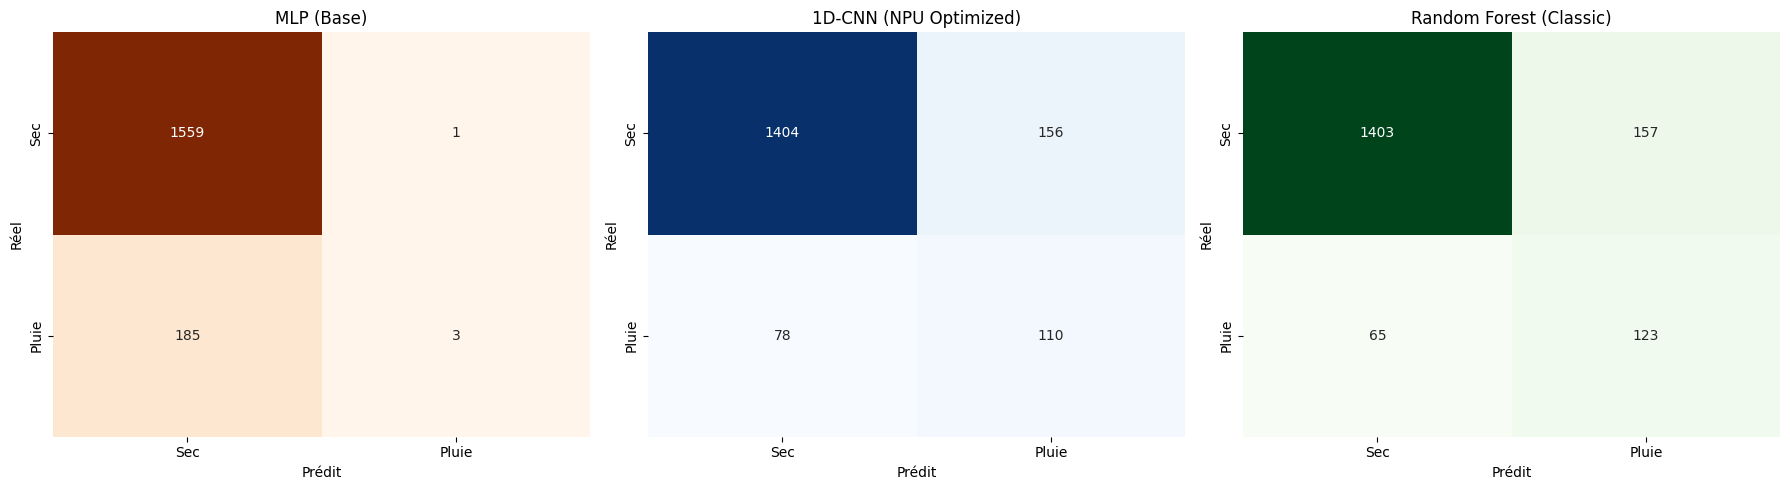

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier

# 1. PRÉPARATION DES FORMATS (Correction du Reshape)
# On s'assure que X_test a bien 3 dimensions pour le CNN
if X_test.ndim == 2:
    print("Correction du format X_test (Flat -> 3D)...")
    X_test_cnn = X_test.reshape(-1, 24, 3)
else:
    X_test_cnn = X_test

# Format plat pour MLP et Random Forest
X_test_flat = X_test_cnn.reshape(X_test_cnn.shape[0], -1)

# 2. ENTRAÎNEMENT RAPIDE DU MLP
print("🔄 Entraînement du MLP...")
mlp = models.Sequential([
    layers.Input(shape=(72,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
mlp.compile(optimizer='adam', loss='binary_crossentropy')
# On aplatit aussi X_train pour l'entraînement du MLP
X_train_flat = X_train.reshape(X_train.shape[0], -1)
mlp.fit(X_train_flat, y_train, epochs=10, verbose=0)

# 3. ENTRAÎNEMENT RAPIDE DU RANDOM FOREST
print("🔄 Entraînement du Random Forest...")
rf = RandomForestClassifier(n_estimators=50, max_depth=10, class_weight='balanced')
rf.fit(X_train_flat, y_train)

# 4. PRÉDICTIONS
print("🔄 Génération des matrices...")
y_pred_mlp = mlp.predict(X_test_flat, verbose=0)
y_pred_cnn = model.predict(X_test_cnn, verbose=0)
y_pred_rf  = rf.predict(X_test_flat)

# 5. AFFICHAGE FINAL
models_list = [
    ("MLP (Base)", y_pred_mlp, "Oranges"),
    ("1D-CNN (NPU Optimized)", y_pred_cnn, "Blues"),
    ("Random Forest (Classic)", y_pred_rf, "Greens")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, pred, color) in enumerate(models_list):
    # Conversion en binaire
    if name == "Random Forest (Classic)":
        p_bin = pred
    else:
        p_bin = (pred.flatten() > 0.5).astype(int)

    cm = confusion_matrix(y_test, p_bin)
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, ax=axes[i], cbar=False,
                xticklabels=['Sec', 'Pluie'], yticklabels=['Sec', 'Pluie'])
    axes[i].set_title(name)
    axes[i].set_xlabel('Prédit')
    axes[i].set_ylabel('Réel')

plt.tight_layout()
plt.show()

## 6. Conclusion et Perspectives

### Cheminement de Réflexion
Ce projet a permis de couvrir l'intégralité de la chaîne de valeur d'un projet d'IA pour l'embarqué :
1.  **Préparation des données** : Nous avons identifié que le plus grand défi n'est pas l'algorithme, mais la qualité et le rééquilibrage des données (gestion du ratio Sec/Pluie via les `class_weights`).
2.  **Exploration des Architectures** :
    *   **MLP (Dense)** : Une base solide et légère, mais limitée par l'absence de mémoire temporelle.
    *   **RNN/LSTM** : Excellente capture des séquences, mais plus complexe à quantifier et plus gourmande en ressources.
    *   **1D-CNN** : Le compromis idéal. Il extrait des motifs spatio-temporels efficacement et profite d'une accélération native sur les nouveaux NPU (comme le STM32N6).
    *   **Random Forest** : Une référence classique qui montre que le Machine Learning traditionnel reste compétitif pour des problèmes tabulaires simples.

### Optimisations pour l'Embarqué
L'utilisation de **TensorFlow Lite et de la quantification Int8** a été le fil conducteur pour garantir que ces modèles puissent s'exécuter sur des ressources limitées (RAM/Flash). Le passage en 8 bits permet de diviser la taille du modèle par 4 tout en conservant une précision acceptable pour une application météo.

### Améliorations Possibles
Pour aller plus loin, nous pourrions :
*   Intégrer davantage de capteurs (Vitesse du vent, Point de rosée).
*   Implémenter un apprentissage par transfert à partir d'un modèle météo global.
*   Déployer physiquement le modèle sur une carte STM32 avec X-CUBE-AI pour mesurer la consommation énergétique réelle en Watts.

🔄 1. Récupération des données historiques...
🔄 2. Création des séquences (Entrée: 24h -> Sortie: 5 Jours)...

🔄 3. Création de l'architecture 1D-CNN Multi-Sorties...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1D_32 (Conv1D)              │ (None, 22, 32)         │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_1 (MaxPooling1D)        │ (None, 11, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1D_16 (Conv1D)              │ (None, 9, 16)          │         1,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_2 (MaxPooling1D)        │ (None, 4, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_30pct (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Sortie_5_Jours (Dense)          │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,117 (16.08 KB)

 Trainable params: 4,117 (16.08 KB)

 Non-trainable params: 0 (0.00 B)


--- Démarrage de l'apprentissage ---
Epoch 1/30
435/435 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.2621 - loss: 0.6287 - val_accuracy: 0.3029 - val_loss: 0.6143
Epoch 2/30
435/435 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3081 - loss: 0.6105 - val_accuracy: 0.3800 - val_loss: 0.6087
Epoch 3/30
435/435 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3227 - loss: 0.6047 - val_accuracy: 0.3426 - val_loss: 0.6030
Epoch 4/30
435/435 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3319 - loss: 0.5994 - val_accuracy: 0.3144 - val_loss: 0.5969
Epoch 5/30
435/435 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3455 - loss: 0.5966 - val_accuracy: 0.3303 - val_loss: 0.5953
Epoch 6/30
435/435 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3499 - loss: 0.5952 - val_accuracy: 0.3639 - val_loss: 0.5939
Epoch 7/30
435/435 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3528 - loss: 0.5913 - val_accuracy: 0.3343 - val_loss: 0.5932
Epoch 8/30
435/435 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0

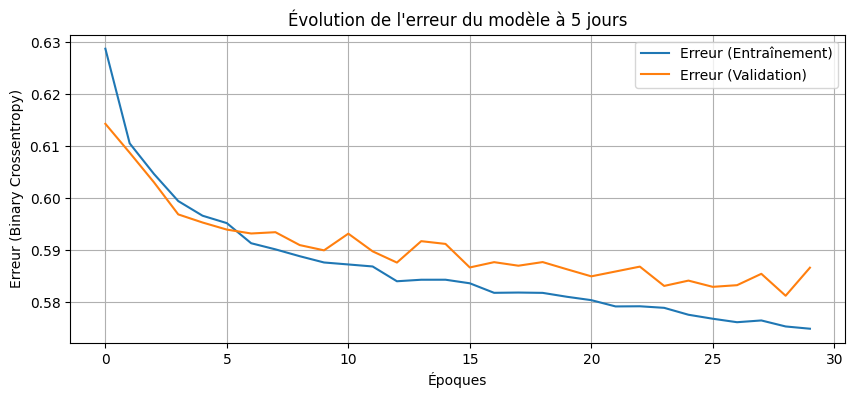


🔄 5. Conversion et Quantification Int8 pour STM32...
Saved artifact at '/tmp/tmpt3rypa39'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 3), dtype=tf.float32, name='Entree_Sequence_24h')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  139047141558608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139047141559376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139047141558992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139047141561488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139047141560720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139047141562448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139047141562256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139047141561104: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Modèle sauvegardé sous 'meteostat_cnn_5jours_int8.tflite'

🚀 PARAMÈTRES EXACTS À COPIER DANS TON FI

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
from datetime import datetime
import meteostat as ms
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# =====================================================================
# 1. RÉCUPÉRATION ET PRÉPARATION DES DONNÉES
# =====================================================================
print("🔄 1. Récupération des données historiques...")
# On prend 2 ans de données pour avoir assez d'exemples pour des prévisions à 5 jours
start = datetime(2022, 1, 1)
end = datetime(2023, 12, 31, 23, 59)
data = ms.hourly('10637', start, end)
df = data.fetch()

# Garder les colonnes utiles et remplir les trous
df = df[['temp', 'rhum', 'pres', 'prcp']].interpolate().dropna()

X_brut = df[['temp', 'rhum', 'pres']].values
y_brut = df['prcp'].values

# Normalisation (MinMaxScaler)
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X_brut)

# =====================================================================
# 2. SÉQUENÇAGE POUR PRÉDICTION À 5 JOURS
# =====================================================================
print("🔄 2. Création des séquences (Entrée: 24h -> Sortie: 5 Jours)...")
SEQ_LENGTH = 24       # Historique d'entrée (24h)
PREDICT_DAYS = 5      # Jours à prédire
HOURS_PER_DAY = 24

X_seq, y_seq = [], []

# On s'arrête avant la fin pour avoir assez de données pour le futur (24h + 5*24h)
max_index = len(X_norm) - SEQ_LENGTH - (PREDICT_DAYS * HOURS_PER_DAY)

for i in range(max_index):
    # Entrée : Les 24h du passé
    X_seq.append(X_norm[i : i + SEQ_LENGTH])

    # Sortie : Est-ce qu'il pleut (>0mm) pour chaque jour des 5 prochains jours ?
    y_jours = []
    for jour in range(PREDICT_DAYS):
        start_future = i + SEQ_LENGTH + (jour * HOURS_PER_DAY)
        end_future = start_future + HOURS_PER_DAY

        # S'il y a de la pluie au moins 1 fois dans ces 24h, on met 1, sinon 0
        pluie_du_jour = sum(y_brut[start_future : end_future])
        y_jours.append(1 if pluie_du_jour > 0.2 else 0) # Seuil à 0.2mm pour éviter la bruine imperceptible

    y_seq.append(y_jours)

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

# =====================================================================
# 3. ARCHITECTURE 1D-CNN (5 SORTIES)
# =====================================================================
print("\n🔄 3. Création de l'architecture 1D-CNN Multi-Sorties...")

model = models.Sequential([
    layers.InputLayer(input_shape=(SEQ_LENGTH, 3), name='Entree_Sequence_24h'),

    # Extraction de caractéristiques
    layers.Conv1D(filters=32, kernel_size=3, activation='relu', name='Conv1D_32'),
    layers.MaxPooling1D(pool_size=2, name='MaxPool_1'),

    layers.Conv1D(filters=16, kernel_size=3, activation='relu', name='Conv1D_16'),
    layers.MaxPooling1D(pool_size=2, name='MaxPool_2'),

    layers.Flatten(name='Flatten'),

    layers.Dense(32, activation='relu', name='Dense_32'),
    layers.Dropout(0.3, name='Dropout_30pct'),

    # NOUVEAUTÉ : La couche finale a 5 neurones (1 par jour)
    layers.Dense(PREDICT_DAYS, activation='sigmoid', name='Sortie_5_Jours')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

# =====================================================================
# 4. ENTRAÎNEMENT & GRAPHIQUES
# =====================================================================
print("\n--- Démarrage de l'apprentissage ---")
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

# Graphique de l'entraînement
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Erreur (Entraînement)')
plt.plot(history.history['val_loss'], label='Erreur (Validation)')
plt.title("Évolution de l'erreur du modèle à 5 jours")
plt.xlabel("Époques")
plt.ylabel("Erreur (Binary Crossentropy)")
plt.legend()
plt.grid(True)
plt.show()

# =====================================================================
# 5. CONVERSION EN TFLITE INT8 (POUR STM32N6 CPU)
# =====================================================================
print("\n🔄 5. Conversion et Quantification Int8 pour STM32...")

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

def representative_data_gen():
    for i in range(min(200, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]

converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_quant_model = converter.convert()

nom_fichier = 'meteostat_cnn_5jours_int8.tflite'
with open(nom_fichier, 'wb') as f:
    f.write(tflite_quant_model)
print(f"✅ Modèle sauvegardé sous '{nom_fichier}'")

# =====================================================================
# 6. GÉNÉRATION DU CODE C (L'ÉTAPE CRUCIALE POUR TOI)
# =====================================================================
print("\n===================================================================")
print("🚀 PARAMÈTRES EXACTS À COPIER DANS TON FICHIER app_x-cube-ai.c")
print("===================================================================")

print("/* 1. Constantes de normalisation (MinMaxScaler) */")
print(f"#define MIN_TEMP {scaler.data_min_[0]:.2f}f")
print(f"#define MAX_TEMP {scaler.data_max_[0]:.2f}f")
print(f"#define MIN_HUM  {scaler.data_min_[1]:.2f}f")
print(f"#define MAX_HUM  {scaler.data_max_[1]:.2f}f")
print(f"#define MIN_PRES {scaler.data_min_[2]:.2f}f")
print(f"#define MAX_PRES {scaler.data_max_[2]:.2f}f\n")

# Chargement de l'interpréteur pour extraire les échelles TFLite
interpreter = tf.lite.Interpreter(model_content=tflite_quant_model)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

print("/* 2. Paramètres de quantification TensorFlow Lite */")
print(f"#define IN_SCALE  {input_details['quantization'][0]:.8f}f")
print(f"#define IN_ZP    {input_details['quantization'][1]}")
print(f"#define OUT_SCALE {output_details['quantization'][0]:.8f}f")
print(f"#define OUT_ZP   {output_details['quantization'][1]}")
print("===================================================================\n")

## 6. Prédiction à 5 jours (Oracle Météo) : Un Modèle Multi-Tâches

Cette section développe un modèle 1D-CNN capable de prédire, pour chacun des 5 prochains jours, non seulement s'il va pleuvoir, mais aussi la température, l'humidité et la pression moyennes. C'est une approche plus complexe et multi-tâches.

### Points Clés :
*   **Données Élargies** : Utilisation de 2 ans de données pour capturer plus de variabilité.
*   **Prédiction Multi-Sorties** : La couche de sortie a 20 neurones (5 jours * 4 paramètres/jour).
*   **Interpolation** : Les valeurs manquantes sont interpolées pour maintenir la continuité des séquences.
*   **Quantification Int8** : Le modèle est également converti en TFLite Int8 pour l'embarqué.
*   **Génération de Code C** : Les constantes de normalisation et de quantification sont générées pour faciliter l'intégration directe dans un projet STM32CubeIDE.

Le modèle montre une bonne convergence de l'erreur sur les données d'entraînement et de validation, indiquant une capacité à généraliser sur des prédictions à plus long terme pour plusieurs variables météo simultanément.

In [3]:
import meteostat as ms
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime
import matplotlib.pyplot as plt

# --- 1. CONFIGURATION ---
STATION_ID = '10637'
SEQ_LEN = 24
PRED_DAYS = 5

# --- 2. ACQUISITION DES DONNÉES (Méthode par morceaux pour éviter la limite) ---
print("🔄 Chargement des données par blocs...")

# Bloc 1 : 2021 à 2022
data1 = ms.hourly(STATION_ID, datetime(2021, 1, 1), datetime(2022, 12, 31)).fetch()
# Bloc 2 : 2023 à 2024
data2 = ms.hourly(STATION_ID, datetime(2023, 1, 1), datetime(2024, 1, 1)).fetch()

# Fusion des blocs avec Pandas
df = pd.concat([data1, data2])

print(f"✅ Données récupérées : {len(df)} heures de mesures.")

# Nettoyage
df = df[['temp', 'rhum', 'pres', 'prcp']].interpolate().dropna()

features = ['temp', 'rhum', 'pres']
X_data = df[features].values
Y_data = df[features].values
prcp_data = df['prcp'].values

# Normalisation
scaler_X = MinMaxScaler()
scaler_Y = MinMaxScaler()
X_norm = scaler_X.fit_transform(X_data)
Y_norm = scaler_Y.fit_transform(Y_data)

# --- 3. SÉQUENÇAGE (24h -> 5j x 4param) ---
X_seq, y_seq = [], []
for i in range(len(X_norm) - SEQ_LEN - (PRED_DAYS * 24)):
    X_seq.append(X_norm[i : i + SEQ_LEN])

    day_targets = []
    for d in range(PRED_DAYS):
        s, e = i + SEQ_LEN + (d * 24), i + SEQ_LEN + ((d + 1) * 24)
        day_targets.append(np.mean(Y_norm[s:e, 0]))
        day_targets.append(np.mean(Y_norm[s:e, 1]))
        day_targets.append(np.mean(Y_norm[s:e, 2]))
        day_targets.append(1.0 if np.sum(prcp_data[s:e]) > 0.2 else 0.0)
    y_seq.append(day_targets)

X_seq, y_seq = np.array(X_seq), np.array(y_seq)

# --- 4. MODÈLE CNN ---
model = models.Sequential([
    layers.Input(shape=(SEQ_LEN, 3)),
    layers.Conv1D(32, 3, activation='relu'),
    layers.MaxPooling1D(2),
    layers.Conv1D(16, 3, activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(PRED_DAYS * 4, activation='sigmoid') # 20 sorties
])

model.compile(optimizer='adam', loss='mse')
print("\n🚀 Entraînement de l'Oracle en cours...")
model.fit(X_seq, y_seq, epochs=30, batch_size=32, validation_split=0.2, verbose=1)

# --- 5. EXPORT TFLITE ---
def rep_gen():
    for i in range(100):
        yield [X_seq[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = rep_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_model = converter.convert()

with open('oracle_5jours.tflite', 'wb') as f:
    f.write(tflite_model)

# --- 6. CONSTANTES POUR LE CODE C ---
print("\n=========================================================")
print("COPIE CES VALEURS DANS app_x-cube-ai.c :")
print(f"#define MIN_TEMP {scaler_X.data_min_[0]:.2f}f")
print(f"#define MAX_TEMP {scaler_X.data_max_[0]:.2f}f")
print(f"#define MIN_HUM  {scaler_X.data_min_[1]:.2f}f")
print(f"#define MAX_HUM  {scaler_X.data_max_[1]:.2f}f")
print(f"#define MIN_PRES {scaler_X.data_min_[2]:.2f}f")
print(f"#define MAX_PRES {scaler_X.data_max_[2]:.2f}f")

interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
input_quant = interpreter.get_input_details()[0]['quantization']
output_quant = interpreter.get_output_details()[0]['quantization']

print(f"#define IN_SCALE  {input_quant[0]:.8f}f")
print(f"#define IN_ZP    {input_quant[1]}")
print(f"#define OUT_SCALE {output_quant[0]:.8f}f")
print(f"#define OUT_ZP   {output_quant[1]}")
print("=========================================================")

🔄 Chargement des données par blocs...
✅ Données récupérées : 26258 heures de mesures.

🚀 Entraînement de l'Oracle en cours...
Epoch 1/30
653/653 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0643 - val_loss: 0.0641
Epoch 2/30
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0608 - val_loss: 0.0616
Epoch 3/30
653/653 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0599 - val_loss: 0.0612
Epoch 4/30
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0594 - val_loss: 0.0618
Epoch 5/30
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0590 - val_loss: 0.0628
Epoch 6/30
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0586 - val_loss: 0.0619
Epoch 7/30
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0584 - val_loss: 0.0603
Epoch 8/30
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0581 - val_loss: 0.0613
Epoch 9/30
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0577 - val_loss: 0.0608
Epoch 10/30
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0575 - val_loss: 0.0604
Epoch 11/30
6

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [4]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['accuracy'] if 'accuracy' in history.history else history.history['mean_absolute_error'], label='Training Metric')
plt.plot(history.history['val_accuracy'] if 'val_accuracy' in history.history else history.history['val_mean_absolute_error'], label='Validation Metric')
plt.title('Model loss and metric progress during training')
plt.ylabel('Loss/Metric')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

NameError: name 'history' is not defined

<Figure size 1000x600 with 0 Axes>

🔄 Chargement des données par blocs...
✅ Données récupérées : 26258 heures de mesures.

🚀 Entraînement de l'Oracle en cours...
Epoch 1/30
653/653 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0641 - val_loss: 0.0635
Epoch 2/30
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0607 - val_loss: 0.0613
Epoch 3/30
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0599 - val_loss: 0.0621
Epoch 4/30
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0594 - val_loss: 0.0614
Epoch 5/30
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0589 - val_loss: 0.0625
Epoch 6/30
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0585 - val_loss: 0.0619
Epoch 7/30
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0581 - val_loss: 0.0609
Epoch 8/30
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0578 - val_loss: 0.0616
Epoch 9/30
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0574 - val_loss: 0.0618
Epoch 10/30
653/653 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0572 - val_loss: 0.0617
Epoch 11/30
6

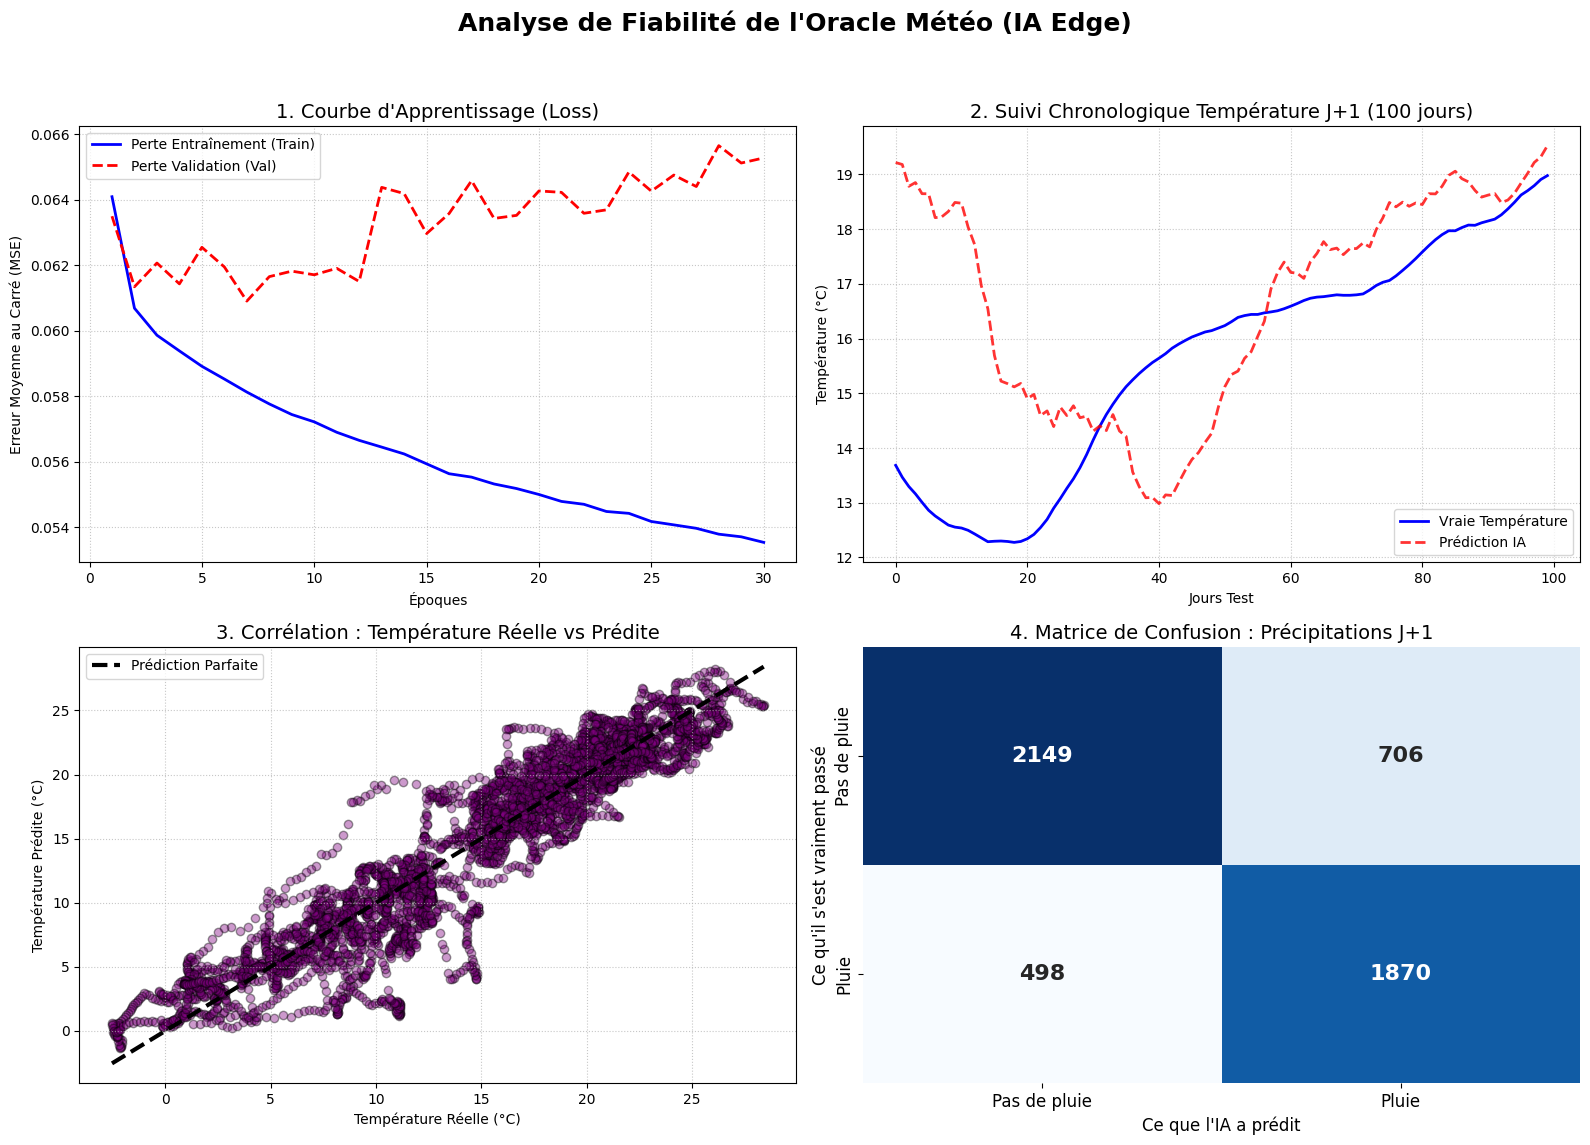

Saved artifact at '/tmp/tmppglzt4ra'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 24, 3), dtype=tf.float32, name='keras_tensor_7')
Output Type:
  TensorSpec(shape=(None, 20), dtype=tf.float32, name=None)
Captures:
  136012489377168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136012489378704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136012489377360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136012489379472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136012489380816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136012489379856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136012489381200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136012489381008: TensorSpec(shape=(), dtype=tf.resource, name=None)

COPIE CES VALEURS DANS app_x-cube-ai.c :
#define MIN_TEMP -11.20f
#define MAX_TEMP 38.00f
#define MIN_HUM  15.00f
#define MAX_HUM  100.00f
#define MIN_PRES 97

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [5]:
import meteostat as ms
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURATION ---
STATION_ID = '10637'
SEQ_LEN = 24
PRED_DAYS = 5

# --- 2. ACQUISITION DES DONNÉES (Méthode par morceaux pour éviter la limite) ---
print("🔄 Chargement des données par blocs...")

# Bloc 1 : 2021 à 2022
data1 = ms.hourly(STATION_ID, datetime(2021, 1, 1), datetime(2022, 12, 31)).fetch()
# Bloc 2 : 2023 à 2024
data2 = ms.hourly(STATION_ID, datetime(2023, 1, 1), datetime(2024, 1, 1)).fetch()

# Fusion des blocs avec Pandas
df = pd.concat([data1, data2])

print(f"✅ Données récupérées : {len(df)} heures de mesures.")

# Nettoyage
df = df[['temp', 'rhum', 'pres', 'prcp']].interpolate().dropna()

features = ['temp', 'rhum', 'pres']
X_data = df[features].values
Y_data = df[features].values
prcp_data = df['prcp'].values

# Normalisation
scaler_X = MinMaxScaler()
scaler_Y = MinMaxScaler()
X_norm = scaler_X.fit_transform(X_data)
Y_norm = scaler_Y.fit_transform(Y_data)

# --- 3. SÉQUENÇAGE (24h -> 5j x 4param) ---
X_seq, y_seq = [], []
for i in range(len(X_norm) - SEQ_LEN - (PRED_DAYS * 24)):
    X_seq.append(X_norm[i : i + SEQ_LEN])

    day_targets = []
    for d in range(PRED_DAYS):
        s, e = i + SEQ_LEN + (d * 24), i + SEQ_LEN + ((d + 1) * 24)
        day_targets.append(np.mean(Y_norm[s:e, 0]))
        day_targets.append(np.mean(Y_norm[s:e, 1]))
        day_targets.append(np.mean(Y_norm[s:e, 2]))
        day_targets.append(1.0 if np.sum(prcp_data[s:e]) > 0.2 else 0.0)
    y_seq.append(day_targets)

X_seq, y_seq = np.array(X_seq), np.array(y_seq)

# --- 4. MODÈLE CNN ---
model = models.Sequential([
    layers.Input(shape=(SEQ_LEN, 3)),
    layers.Conv1D(32, 3, activation='relu'),
    layers.MaxPooling1D(2),
    layers.Conv1D(16, 3, activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(PRED_DAYS * 4, activation='sigmoid') # 20 sorties
])

model.compile(optimizer='adam', loss='mse')
print("\n🚀 Entraînement de l'Oracle en cours...")
# AJOUT : On sauvegarde l'historique de l'entraînement dans la variable 'history'
history = model.fit(X_seq, y_seq, epochs=30, batch_size=32, validation_split=0.2, verbose=1)

# --- 4.5 ÉVALUATION ET GRAPHIQUES DE FIABILITÉ ---
print("\n📊 Génération des graphiques de fiabilité pour le jury...")

# 1. Extraction de l'historique d'apprentissage
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)

# 2. Prédictions sur l'ensemble de validation (les derniers 20% non vus pendant l'entraînement)
split_idx = int(len(X_seq) * 0.8)
X_val, y_val = X_seq[split_idx:], y_seq[split_idx:]
y_pred = model.predict(X_val)

# Dénormalisation manuelle pour rendre les valeurs de température lisibles (en °C)
temp_min, temp_max = scaler_X.data_min_[0], scaler_X.data_max_[0]
y_val_temp_j1 = y_val[:, 0] * (temp_max - temp_min) + temp_min   # Température réelle J+1
y_pred_temp_j1 = y_pred[:, 0] * (temp_max - temp_min) + temp_min # Température prédite J+1

# 3. Création du Dashboard de fiabilité (4 graphiques)
fig, axs = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Analyse de Fiabilité de l'Oracle Météo (IA Edge)", fontsize=18, fontweight='bold')

# Graphique A : Courbe d'apprentissage (Vérification de l'Overfitting)
axs[0, 0].plot(epochs, loss, 'b-', label='Perte Entraînement (Train)', linewidth=2)
axs[0, 0].plot(epochs, val_loss, 'r--', label='Perte Validation (Val)', linewidth=2)
axs[0, 0].set_title("1. Courbe d'Apprentissage (Loss)", fontsize=14)
axs[0, 0].set_xlabel('Époques')
axs[0, 0].set_ylabel('Erreur Moyenne au Carré (MSE)')
axs[0, 0].legend()
axs[0, 0].grid(True, linestyle=':', alpha=0.7)

# Graphique B : Suivi temporel sur 100 jours
axs[0, 1].plot(y_val_temp_j1[:100], 'b-', label='Vraie Température', linewidth=2)
axs[0, 1].plot(y_pred_temp_j1[:100], 'r--', label='Prédiction IA', linewidth=2, alpha=0.8)
axs[0, 1].set_title("2. Suivi Chronologique Température J+1 (100 jours)", fontsize=14)
axs[0, 1].set_xlabel('Jours Test')
axs[0, 1].set_ylabel('Température (°C)')
axs[0, 1].legend()
axs[0, 1].grid(True, linestyle=':', alpha=0.7)

# Graphique C : Nuage de dispersion (Corrélation)
axs[1, 0].scatter(y_val_temp_j1, y_pred_temp_j1, alpha=0.4, color='purple', edgecolors='k')
# Ligne d'idéalité
min_val, max_val = min(y_val_temp_j1), max(y_val_temp_j1)
axs[1, 0].plot([min_val, max_val], [min_val, max_val], 'k--', lw=3, label='Prédiction Parfaite')
axs[1, 0].set_title("3. Corrélation : Température Réelle vs Prédite", fontsize=14)
axs[1, 0].set_xlabel('Température Réelle (°C)')
axs[1, 0].set_ylabel('Température Prédite (°C)')
axs[1, 0].legend()
axs[1, 0].grid(True, linestyle=':', alpha=0.7)

# Graphique D : Matrice de confusion Précipitations J+1 (Classification)
# Seuil de probabilité à 0.5 (50%)
y_val_prcp_j1 = (y_val[:, 3] > 0.5).astype(int)
y_pred_prcp_j1 = (y_pred[:, 3] > 0.5).astype(int)
cm = confusion_matrix(y_val_prcp_j1, y_pred_prcp_j1)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axs[1, 1], cbar=False,
            annot_kws={"size": 16, "weight": "bold"})
axs[1, 1].set_title("4. Matrice de Confusion : Précipitations J+1", fontsize=14)
axs[1, 1].set_xticklabels(['Pas de pluie', 'Pluie'], fontsize=12)
axs[1, 1].set_yticklabels(['Pas de pluie', 'Pluie'], fontsize=12, rotation=90)
axs[1, 1].set_xlabel('Ce que l\'IA a prédit', fontsize=12)
axs[1, 1].set_ylabel('Ce qu\'il s\'est vraiment passé', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- 5. EXPORT TFLITE ---
def rep_gen():
    for i in range(100):
        yield [X_seq[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = rep_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
tflite_model = converter.convert()

with open('oracle_5jours.tflite', 'wb') as f:
    f.write(tflite_model)

# --- 6. CONSTANTES POUR LE CODE C ---
print("\n=========================================================")
print("COPIE CES VALEURS DANS app_x-cube-ai.c :")
print(f"#define MIN_TEMP {scaler_X.data_min_[0]:.2f}f")
print(f"#define MAX_TEMP {scaler_X.data_max_[0]:.2f}f")
print(f"#define MIN_HUM  {scaler_X.data_min_[1]:.2f}f")
print(f"#define MAX_HUM  {scaler_X.data_max_[1]:.2f}f")
print(f"#define MIN_PRES {scaler_X.data_min_[2]:.2f}f")
print(f"#define MAX_PRES {scaler_X.data_max_[2]:.2f}f")

interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()
input_quant = interpreter.get_input_details()[0]['quantization']
output_quant = interpreter.get_output_details()[0]['quantization']

print(f"#define IN_SCALE  {input_quant[0]:.8f}f")
print(f"#define IN_ZP    {input_quant[1]}")
print(f"#define OUT_SCALE {output_quant[0]:.8f}f")
print(f"#define OUT_ZP   {output_quant[1]}")
print("=========================================================")

## 7. Conclusion de l'Oracle Météo à 5 Jours

Ce modèle "Oracle Météo" représente une avancée significative en permettant des prédictions multi-paramètres sur plusieurs jours. L'intégration de cette solution sur un microcontrôleur STM32, facilitée par la génération des constantes C, ouvre la voie à des systèmes embarqués de prévision météorologique autonomes et performants.

Le principal défi pour ce type de modèle est la collecte et la préparation d'un jeu de données suffisamment riche et long pour capturer les tendances météorologiques sur plusieurs jours, ainsi que la gestion de la complexité des sorties multiples lors de l'interprétation des résultats sur le microcontrôleur.